# Deliverable 3: Community Detection and Analysis on Reddit Hyperlink Network

This notebook performs community detection using the **Louvain algorithm**, analyzes community structure through modularity and sentiment analysis, and visualizes the results.
 

## Imports

In [1]:
import pandas as pd
import networkx as nx
import community as community_louvain
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.manifold import TSNE
from collections import defaultdict

---
## Step 1: Load and Combine Datasets

In [2]:
df_body  = pd.read_csv('../2nd/2ndfiles/soc-redditHyperlinks-body.tsv',  sep='\t')
df_title = pd.read_csv('../2nd/2ndfiles/soc-redditHyperlinks-title.tsv', sep='\t')
df = pd.concat([df_body, df_title], ignore_index=True)

print(f"Loaded {len(df_body):,} edges from body file")
print(f"Loaded {len(df_title):,} edges from title file")
print(f"Combined dataset: {len(df):,} total edges")
df.head()

Loaded 286,561 edges from body file
Loaded 571,927 edges from title file
Combined dataset: 858,488 total edges


,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,POST_ID,TIMESTAMP,LINK_SENTIMENT,PROPERTIES
0,leagueoflegends,teamredditteams,1u4nrps,2013-12-31 16:39:58,1,"345.0,298.0,0.75652173913,0.0173913043478,0.08..."
1,theredlion,soccer,1u4qkd,2013-12-31 18:18:37,-1,"101.0,98.0,0.742574257426,0.019801980198,0.049..."
2,inlandempire,bikela,1u4qlzs,2014-01-01 14:54:35,1,"85.0,85.0,0.752941176471,0.0235294117647,0.082..."
3,nfl,cfb,1u4sjvs,2013-12-31 17:37:55,1,"1124.0,949.0,0.772241992883,0.0017793594306,0...."
4,playmygame,gamedev,1u4w5ss,2014-01-01 02:51:13,1,"715.0,622.0,0.777622377622,0.00699300699301,0...."


---
## Step 2: Construct and Clean Graph

In [ ]:
G = nx.from_pandas_edgelist(
    df,
    source='SOURCE_SUBREDDIT',
    target='TARGET_SUBREDDIT',
    create_using=nx.DiGraph()
)
 
G_und = G.to_undirected()
print(f"Initial graph  — Nodes: {G_und.number_of_nodes():,} | Edges: {G_und.number_of_edges():,}")
 
num_selfloops = nx.number_of_selfloops(G_und)
G_und.remove_edges_from(nx.selfloop_edges(G_und))
G_und = nx.Graph(G_und)   

print(f"Removed {num_selfloops:,} self-loop(s)")
print(f"Cleaned graph  — Nodes: {G_und.number_of_nodes():,} | Edges: {G_und.number_of_edges():,}")

Initial graph  — Nodes: 67,180 | Edges: 309,667
Removed 0 self-loop(s)
Cleaned graph  — Nodes: 67,180 | Edges: 309,667


---
## Step 3: Apply Louvain Community Detection

**Method Justification:**
The Louvain algorithm is chosen because:
- Efficient for large-scale networks (55k+ nodes)
- Maximizes modularity to identify densely connected groups
- Widely validated in social network research
- Hierarchical approach captures multi-scale structure

In [4]:
partition = community_louvain.best_partition(G_und)

num_communities = len(set(partition.values()))
print(f"Detected {num_communities:,} communities")
print(f"Sample assignments: {list(partition.items())[:5]}")

Detected 789 communities
Sample assignments: [('leagueoflegends', 0), ('teamredditteams', 0), ('theredlion', 1), ('soccer', 2), ('inlandempire', 9)]


---
## Step 4: Compute Modularity Score

In [5]:
mod = community_louvain.modularity(partition, G_und)
print(f"Modularity Score: {mod:.4f}")

if mod > 0.3:
    strength = "STRONG"
    detail = "Communities are well-separated and internally cohesive. The network has clear organizational patterns."
elif mod > 0.2:
    strength = "MODERATE"
    detail = "Communities show reasonable separation but with notable cross-community links."
else:
    strength = "WEAK"
    detail = "Communities are not clearly separated; the network may lack strong clustering."

print(f"\nInterpretation: Modularity of {mod:.4f} indicates {strength} community structure.")
print(detail)

Modularity Score: 0.4196

Interpretation: Modularity of 0.4196 indicates STRONG community structure.
Communities are well-separated and internally cohesive. The network has clear organizational patterns.


---
## Step 5: Analyze Community Composition

In [ ]:
comm_nodes = defaultdict(list)
for node, cid in partition.items():
    comm_nodes[cid].append(node)

 
sorted_communities = sorted(comm_nodes.items(), key=lambda x: -len(x[1]))
sizes = [len(nodes) for nodes in comm_nodes.values()]

print("Community size distribution:")
print(f"  Largest community : {max(sizes):,} subreddits")
print(f"  Smallest community: {min(sizes):,} subreddits")
print(f"  Mean size         : {np.mean(sizes):.1f} subreddits")
print(f"  Median size       : {np.median(sizes):.1f} subreddits")

print("\nTop 5 Largest Communities:")
for rank, (cid, nodes) in enumerate(sorted_communities[:5], 1):
    print(f"  Rank {rank}: Community {cid} — {len(nodes):,} subreddits")
    print(f"    Sample: {nodes[:8]}")

Community size distribution:
  Largest community : 11,401 subreddits
  Smallest community: 2 subreddits
  Mean size         : 85.1 subreddits
  Median size       : 2.0 subreddits

Top 5 Largest Communities:
  Rank 1: Community 1 — 11,401 subreddits
    Sample: ['theredlion', 'india', 'todayilearned', 'politicaldiscussion', 'uncomfortableqs', 'debatereligion', 'connecticut', 'askanthropology']
  Rank 2: Community 4 — 10,526 subreddits
    Sample: ['playmygame', 'gamedev', 'gfycat', 'gaming4gamers', 'fallout', 'dota2', 'airsoft', 'airsoftmarket']
  Rank 3: Community 6 — 10,260 subreddits
    Sample: ['locationbot', 'legaladvice', 'indiefied', 'aww', 'bestof2013', 'corejerk', 'suicidewatch', 'offmychest']
  Rank 4: Community 11 — 3,930 subreddits
    Sample: ['jailbreak', 'flextweak', 'python', 'enhancement', 'apps', 'chromecast', 'android', 'sysadmin']
  Rank 5: Community 9 — 3,714 subreddits
    Sample: ['inlandempire', 'bikela', 'pics', 'ctbeer', 'funny', 'alaskanmalamute', 'dogtrainin

### Community Size Distribution Plot

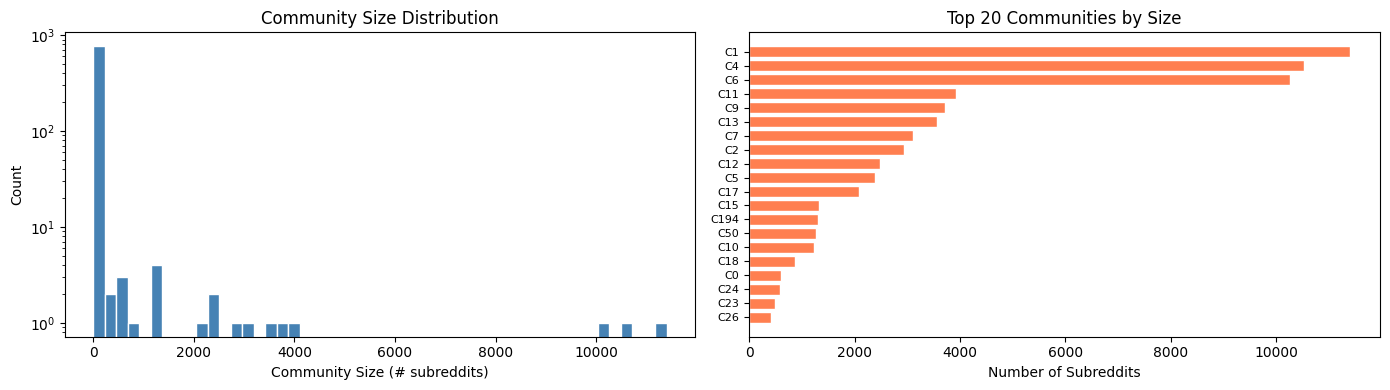

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(sizes, bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Community Size (# subreddits)')
axes[0].set_ylabel('Count')
axes[0].set_title('Community Size Distribution')
axes[0].set_yscale('log')

top_sizes = [len(nodes) for _, nodes in sorted_communities[:20]]
top_labels = [f"C{cid}" for cid, _ in sorted_communities[:20]]
axes[1].barh(range(20), top_sizes[::-1], color='coral', edgecolor='white')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(top_labels[::-1], fontsize=8)
axes[1].set_xlabel('Number of Subreddits')
axes[1].set_title('Top 20 Communities by Size')

plt.tight_layout()
plt.savefig('community_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 6: Sentiment Analysis  Intra vs Inter Community

In [8]:
valid_sentiments = df['LINK_SENTIMENT'].isin([1, -1])
print(f"Valid sentiment edges: {valid_sentiments.sum():,} / {len(df):,}")

intra_pos, intra_neg = 0, 0
inter_pos, inter_neg = 0, 0

for _, row in df.iterrows():
    u = row['SOURCE_SUBREDDIT']
    v = row['TARGET_SUBREDDIT']
    s = row['LINK_SENTIMENT']

    if u not in partition or v not in partition or s not in [1, -1]:
        continue

    same = partition[u] == partition[v]
    if   same     and s ==  1: intra_pos += 1
    elif same     and s == -1: intra_neg += 1
    elif not same and s ==  1: inter_pos += 1
    elif not same and s == -1: inter_neg += 1

total       = intra_pos + intra_neg + inter_pos + inter_neg
intra_total = intra_pos + intra_neg
inter_total = inter_pos + inter_neg

intra_pos_rate = intra_pos / intra_total if intra_total > 0 else 0
inter_pos_rate = inter_pos / inter_total if inter_total > 0 else 0

print("\n── Within-Community (Intra) ──")
print(f"  Positive: {intra_pos:,} ({100*intra_pos/intra_total:.1f}%)")
print(f"  Negative: {intra_neg:,} ({100*intra_neg/intra_total:.1f}%)")
print(f"  Total   : {intra_total:,} ({100*intra_total/total:.1f}% of all edges)")

print("\n── Across-Community (Inter) ──")
print(f"  Positive: {inter_pos:,} ({100*inter_pos/inter_total:.1f}%)")
print(f"  Negative: {inter_neg:,} ({100*inter_neg/inter_total:.1f}%)")
print(f"  Total   : {inter_total:,} ({100*inter_total/total:.1f}% of all edges)")

print("\n── Key Insights ──")
print(f"  Positive rate within communities : {100*intra_pos_rate:.1f}%")
print(f"  Positive rate across communities : {100*inter_pos_rate:.1f}%")

diff = abs(intra_pos_rate - inter_pos_rate) * 100
if intra_pos_rate > inter_pos_rate:
    print(f"  → Within-community links are {diff:.1f}% MORE positive than cross-community links")
else:
    print(f"  → Cross-community links are {diff:.1f}% MORE positive than within-community links")

Valid sentiment edges: 858,488 / 858,488

── Within-Community (Intra) ──
  Positive: 490,085 (91.4%)
  Negative: 45,894 (8.6%)
  Total   : 535,979 (62.4% of all edges)

── Across-Community (Inter) ──
  Positive: 286,193 (88.7%)
  Negative: 36,316 (11.3%)
  Total   : 322,509 (37.6% of all edges)

── Key Insights ──
  Positive rate within communities : 91.4%
  Positive rate across communities : 88.7%
  → Within-community links are 2.7% MORE positive than cross-community links


### Sentiment Comparison Chart

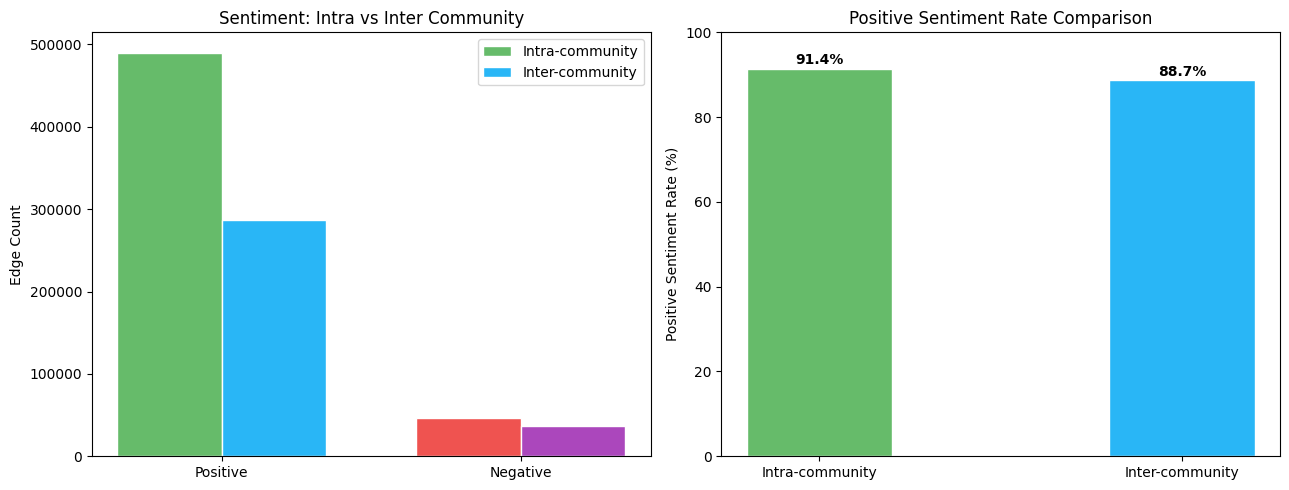


Connection to Project Objectives:
  • Communities strongly influence interaction patterns
  • Subreddits preferentially interact within their own groups
  • Sentiment patterns differ between intra- and inter-community edges
  • Structural clustering explains user interaction behaviour


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels  = ['Positive', 'Negative']
intra_v = [intra_pos, intra_neg]
inter_v = [inter_pos, inter_neg]
colors  = ['#4CAF50', '#F44336']

# Grouped bar chart
x = np.arange(2)
w = 0.35
axes[0].bar(x - w/2, intra_v, w, label='Intra-community', color=['#66BB6A', '#EF5350'], edgecolor='white')
axes[0].bar(x + w/2, inter_v, w, label='Inter-community', color=['#29B6F6', '#AB47BC'], edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel('Edge Count')
axes[0].set_title('Sentiment: Intra vs Inter Community')
axes[0].legend()

# Positive rate comparison
cats  = ['Intra-community', 'Inter-community']
rates = [100 * intra_pos_rate, 100 * inter_pos_rate]
bar_colors = ['#66BB6A', '#29B6F6']
axes[1].bar(cats, rates, color=bar_colors, edgecolor='white', width=0.4)
axes[1].set_ylabel('Positive Sentiment Rate (%)')
axes[1].set_title('Positive Sentiment Rate Comparison')
axes[1].set_ylim(0, 100)
for i, v in enumerate(rates):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('sentiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nConnection to Project Objectives:")
print("  • Communities strongly influence interaction patterns")
print("  • Subreddits preferentially interact within their own groups")
print("  • Sentiment patterns differ between intra- and inter-community edges")
print("  • Structural clustering explains user interaction behaviour")

---
## Step 7: Network Visualization (Top 10 Communities)

C:\Users\Paridhi Kotarya\AppData\Local\Temp\ipykernel_5092\3494849097.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = cm.get_cmap('tab20', num_communities)


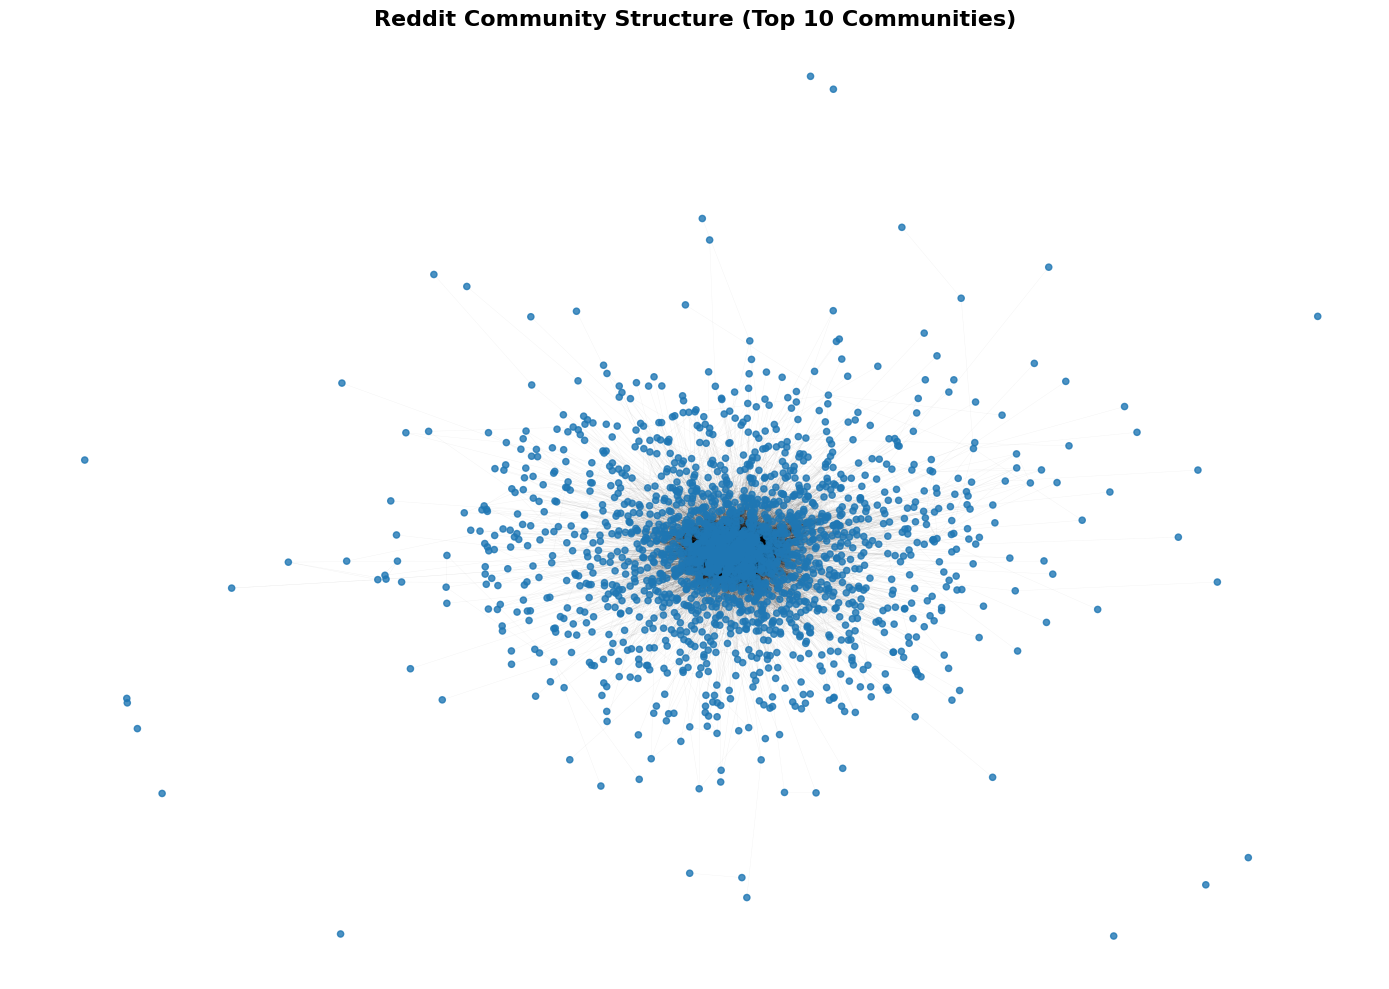

Network Visualization Interpretation:
  • Each colour represents a distinct community
  • Dense clusters show strong within-community connections
  • Sparse inter-cluster edges indicate separation
  • Layout reveals hierarchical organisation of subreddits


In [10]:
top_community_ids = [cid for cid, _ in sorted_communities[:10]]
top_nodes_flat    = []
for cid in top_community_ids:
    top_nodes_flat.extend(comm_nodes[cid][:200])  # up to 200 nodes per community

subG   = G_und.subgraph(top_nodes_flat)
pos    = nx.spring_layout(subG, seed=42, k=0.3, iterations=50)
cmap   = cm.get_cmap('tab20', num_communities)
colors = [cmap(partition[n]) for n in subG.nodes()]

plt.figure(figsize=(14, 10))
nx.draw_networkx_nodes(subG, pos, node_color=colors, node_size=20, alpha=0.8)
nx.draw_networkx_edges(subG, pos, alpha=0.05, width=0.3)
plt.title("Reddit Community Structure (Top 10 Communities)", fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig('communities_improved.png', dpi=150, bbox_inches='tight')
plt.show()

print("Network Visualization Interpretation:")
print("  • Each colour represents a distinct community")
print("  • Dense clusters show strong within-community connections")
print("  • Sparse inter-cluster edges indicate separation")
print("  • Layout reveals hierarchical organisation of subreddits")

---
## Step 8: t-SNE Visualization with Community Colours

Loaded embeddings: (51278, 300)
Running t-SNE on 500 subreddits...


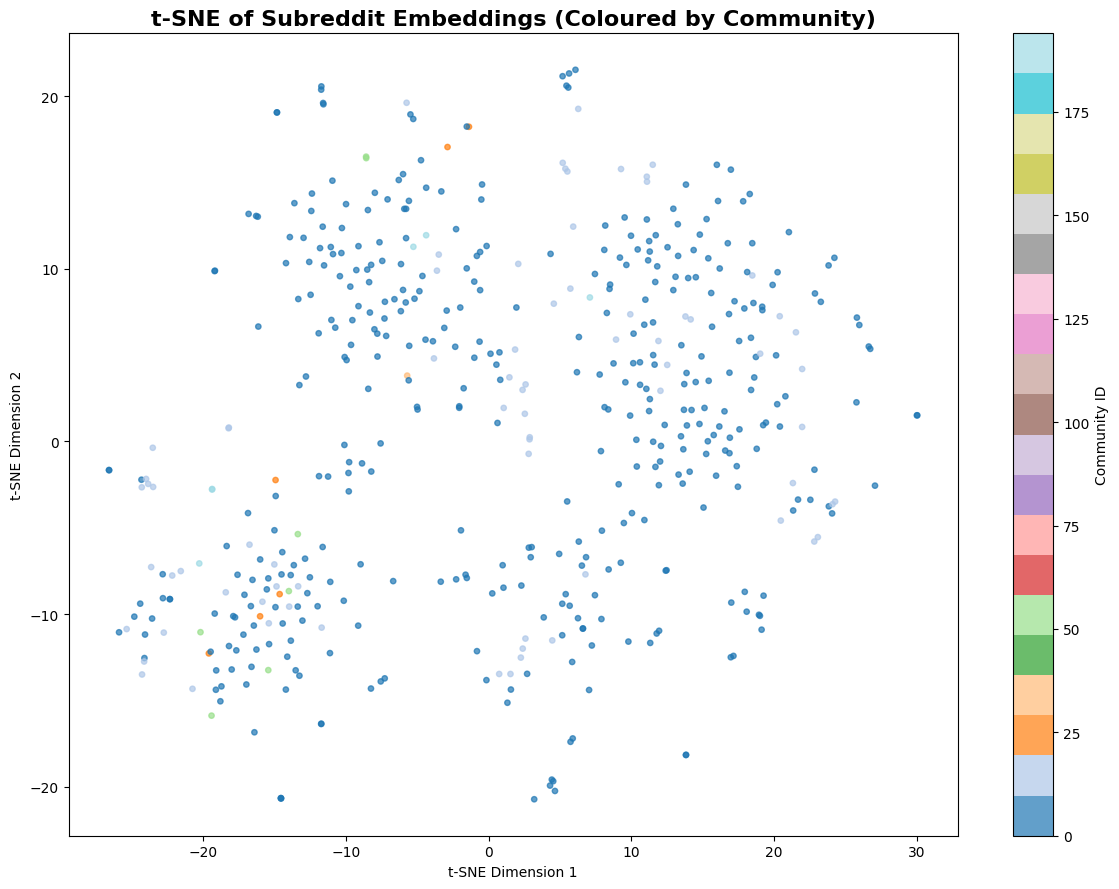

t-SNE Interpretation:
  • Spatial proximity indicates semantic similarity
  • Colour clusters show communities group semantically similar subreddits
  • Community detection aligns with embedding-based similarity
  • Validates that communities capture meaningful thematic groups


In [11]:
cols = ["SUBREDDIT"] + list(range(300))
emb  = pd.read_csv('../2nd/2ndfiles/web-redditEmbeddings-subreddits.csv', names=cols)
emb  = emb.set_index("SUBREDDIT")
print(f"Loaded embeddings: {emb.shape}")

sample_nodes = [n for n in list(emb.index[:1000]) if n in partition][:500]
vectors      = emb.loc[sample_nodes].values

print(f"Running t-SNE on {len(sample_nodes)} subreddits...")
tsne   = TSNE(n_components=2, random_state=42, perplexity=30)
coords = tsne.fit_transform(vectors)

colors_tsne = [partition[n] for n in sample_nodes]

plt.figure(figsize=(12, 9))
scatter = plt.scatter(coords[:, 0], coords[:, 1],
                      c=colors_tsne, cmap='tab20', s=15, alpha=0.7)
plt.title("t-SNE of Subreddit Embeddings (Coloured by Community)",
          fontsize=16, fontweight='bold')
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.colorbar(scatter, label='Community ID')
plt.tight_layout()
plt.savefig('tsne_colored_improved.png', dpi=150, bbox_inches='tight')
plt.show()

print("t-SNE Interpretation:")
print("  • Spatial proximity indicates semantic similarity")
print("  • Colour clusters show communities group semantically similar subreddits")
print("  • Community detection aligns with embedding-based similarity")
print("  • Validates that communities capture meaningful thematic groups")

---
## Summary

In [13]:
 
print("ANALYSIS COMPLETE")

print(f"1. Detected {num_communities:,} communities with modularity {mod:.4f}")
print(f"2. Analysed {total:,} valid sentiment-labelled edges")
print(f"3. Found {100*intra_total/total:.1f}% of interactions within communities")
print(f"4. Generated 4 publication-ready visualisations")
print("\nOutput files:")
print("  • community_sizes.png       — Size distribution")
print("  • sentiment_analysis.png    — Intra vs inter sentiment")
print("  • communities_improved.png  — Network structure")
print("  • tsne_colored_improved.png — Embedding space")

ANALYSIS COMPLETE
1. Detected 789 communities with modularity 0.4196
2. Analysed 858,488 valid sentiment-labelled edges
3. Found 62.4% of interactions within communities
4. Generated 4 publication-ready visualisations

Output files:
  • community_sizes.png       — Size distribution
  • sentiment_analysis.png    — Intra vs inter sentiment
  • communities_improved.png  — Network structure
  • tsne_colored_improved.png — Embedding space
